In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)




### 1. Panoramica generale del dataset

In [43]:
df=pd.read_csv('../data/raw/earthquake_data_tsunami.csv')
df.describe()

,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
count,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000
mean,6.941125,4.333760,5.964194,870.108696,230.250639,1.325757,25.038990,75.883199,3.538100,52.609199,2012.280051,6.563939,0.388747
std,0.445514,3.169939,1.462724,322.465367,250.188177,2.218805,24.225067,137.277078,27.303429,117.898886,6.099439,3.507866,0.487778
min,6.500000,0.000000,1.000000,650.000000,0.000000,0.000000,0.000000,2.700000,-61.848400,-179.968000,2001.000000,1.000000,0.000000
25%,6.600000,0.000000,5.000000,691.000000,0.000000,0.000000,14.625000,14.000000,-14.595600,-71.668050,2007.000000,3.250000,0.000000
50%,6.800000,5.000000,6.000000,754.000000,140.000000,0.000000,20.000000,26.295000,-2.572500,109.426000,2013.000000,7.000000,0.000000
75%,7.100000,7.000000,7.000000,909.750000,445.000000,1.863000,30.000000,49.750000,24.654500,148.941000,2017.000000,10.000000,1.000000
max,9.100000,9.000000,9.000000,2910.000000,934.000000,17.654000,239.000000,670.810000,71.631200,179.662000,2022.000000,12.000000,1.000000


usando la funzione df.describe() possiamo vedere che abbiamo un totale di **728** records.  
Le colonne presenti nel dataset sono:  
- **Magnitude** : che rapprensenta il magnitudo del terremoto (Richter scale) con un range di 6.5 (min) e 9.10 (max).  
- **cdi** : Community Decimal Intensity (intensità percepita dalla popolazione) con un range tra 0 a 9.  
- **mmi** : Intensità del danno osservato (scala Mercalli ) con un range tra 1 a 9.  
- **sign** : Punteggio di significatività dell'evento.  
- **nst** : Numero di stazioni sismiche che hanno registrato l'evento.  
- **dmin** : Distanza angolare dalla stazione più vicina.  
- **gap** : Gap azimutale (copertura azimutale delle stazioni).  
- **depth** : Profondità dell'ipocentro (quanto in profondità si verifica il terremoto).  
- **latitude** : latituidine  
- **longitude**: longitudine   
- **Year** : anno  dal 2001 al 2022
- **Month** : mese  
- **tsunami**: Indicatore che segnala se si è generato uno tsunami  (variabile binaria)



  


In [ ]:
df.isnull().sum()

magnitude    0
cdi          0
mmi          0
sig          0
nst          0
dmin         0
gap          0
depth        0
latitude     0
longitude    0
Year         0
Month        0
tsunami      0
dtype: int64

Un altra cosa importante che notiamo è che **non ci sono valori nulli**

In [56]:
import plotly.graph_objects as go
import plotly.express as px
import pandas as pd

df['tsunami_label'] = df['tsunami'].map({0: 'No Tsunami', 1: 'Tsunami'})
mesi = {0:'Tutti', 1:'Gen', 2:'Feb', 3:'Mar', 4:'Apr', 5:'Mag', 6:'Giu',
        7:'Lug', 8:'Ago', 9:'Set', 10:'Ott', 11:'Nov', 12:'Dic'}

fig = px.scatter_geo(
    df,
    lat='latitude',
    lon='longitude',
    color='tsunami_label',
    color_discrete_map={'Tsunami': '#E07B54', 'No Tsunami': '#4878CF'},
    size='magnitude',
    size_max=18,
    animation_frame='Year',
    projection='natural earth',
    custom_data=['magnitude', 'depth', 'cdi', 'mmi', 'sig',
                 'nst', 'dmin', 'gap', 'Year', 'Month', 'tsunami_label'],
    labels={'tsunami_label': 'Tsunami'}
)

fig.update_traces(
    hovertemplate=(
        '<b>%{customdata[10]}</b><br>'
        '<b>Magnitudo:</b> %{customdata[0]}<br>'
        '<b>Profondità:</b> %{customdata[1]} km<br>'
        '<b>CDI:</b> %{customdata[2]}<br>'
        '<b>MMI:</b> %{customdata[3]}<br>'
        '<b>Significatività:</b> %{customdata[4]}<br>'
        '<b>Stazioni (NST):</b> %{customdata[5]}<br>'
        '<b>DMIN:</b> %{customdata[6]:.2f}<br>'
        '<b>GAP:</b> %{customdata[7]}<br>'
        '<b>Anno:</b> %{customdata[8]}<br>'
        '<b>Mese:</b> %{customdata[9]}<br>'
        '<b>Lat:</b> %{lat:.3f} | <b>Lon:</b> %{lon:.3f}<br>'
        '<extra></extra>'
    ),
    marker=dict(opacity=0.75, line=dict(width=0.5, color='white'))
)

fig.update_layout(
    title=dict(
        text='Distribuzione Geografica Terremoti (2001-2022)',
        font=dict(size=16),
        x=0.5
    ),
    height=600,
    geo=dict(
        projection_type='natural earth',
        showland=True,
        landcolor='#F0EDE8',
        showocean=True,
        oceancolor='#D6EAF8',
        showcoastlines=True,
        coastlinecolor='#AAAAAA',
        showcountries=True,
        countrycolor='#CCCCCC',
        showframe=False,
        lataxis_range=[-70, 80],
        bgcolor='rgba(0,0,0,0)'
    ),
    legend=dict(
        title='Tsunami',
        orientation='v',
        x=1.0,
        y=0.5
    ),
    paper_bgcolor='white',
    plot_bgcolor='white',
    updatemenus=[dict(
        type='buttons',
        showactive=False,
        y=-0.08,
        x=0.1,
        xanchor='left',
        buttons=[
            dict(label='Play',
                 method='animate',
                 args=[None, dict(frame=dict(duration=900, redraw=True),
                                  fromcurrent=True)]),
            dict(label='Stop',
                 method='animate',
                 args=[[None], dict(frame=dict(duration=0),
                                    mode='immediate')])
        ]
    )]
)

fig.update_layout(
    sliders=[{
        'currentvalue': {'prefix': 'Anno: ', 'font': {'size': 14}},
        'pad': {'t': 50},
    }]
)

fig.show()

In [59]:


fig2 = px.scatter_geo(
    df,
    lat='latitude',
    lon='longitude',
    color='tsunami_label',
    color_discrete_map={'Tsunami': '#E07B54', 'No Tsunami': '#4878CF'},
    size='magnitude',
    size_max=18,
    animation_frame='Month',
    projection='natural earth',
    custom_data=['magnitude', 'depth', 'Year', 'Month', 'tsunami_label'],
    title='Distribuzione per Mese (tutti gli anni)',
    labels={'tsunami_label': 'Tsunami', 'Month': 'Mese'}
)

fig2.update_traces(
    hovertemplate=(
        '<b>%{customdata[4]}</b><br>'
        'Magnitudo: %{customdata[0]}<br>'
        'Profondità: %{customdata[1]} km<br>'
        'Anno: %{customdata[2]}<br>'
        'Mese: %{customdata[3]}<br>'
        '<extra></extra>'
    )
)

fig2.update_layout(height=550, paper_bgcolor='white')

fig2.show()

### 2. distribuzione della variabile target tsunami

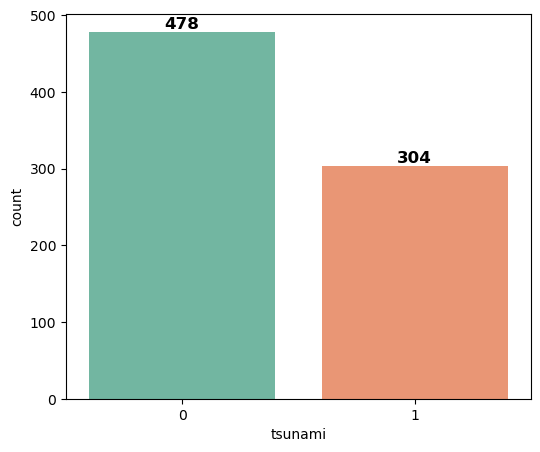

In [44]:
fig, ax = plt.subplots(figsize=(6, 5))
 
ax = sns.countplot(x='tsunami', data=df, palette='Set2', ax=ax)
 
for p in ax.patches:
    ax.annotate(
        int(p.get_height()),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center', va='bottom', fontsize=12, fontweight='bold'
    )


In [26]:
print(df['tsunami'].value_counts())
print(df['tsunami'].value_counts(normalize=True).round(2))

tsunami
0    478
1    304
Name: count, dtype: int64
tsunami
0    0.61
1    0.39
Name: proportion, dtype: float64


Il dataset presenta uno sbilanciamento delle classi:

- Classe 0 (no tsunami): 478 eventi — 61%
- Classe 1 (tsunami): 304 eventi — 39%  

Questo è importante per considerazione da fare per la progettazione del modello di classificazione.  

### 3. DISTRIBUZIONE FEATURE

['magnitude', 'cdi', 'mmi', 'sig', 'nst', 'dmin', 'gap', 'depth', 'latitude', 'longitude', 'Year', 'Month', 'tsunami']


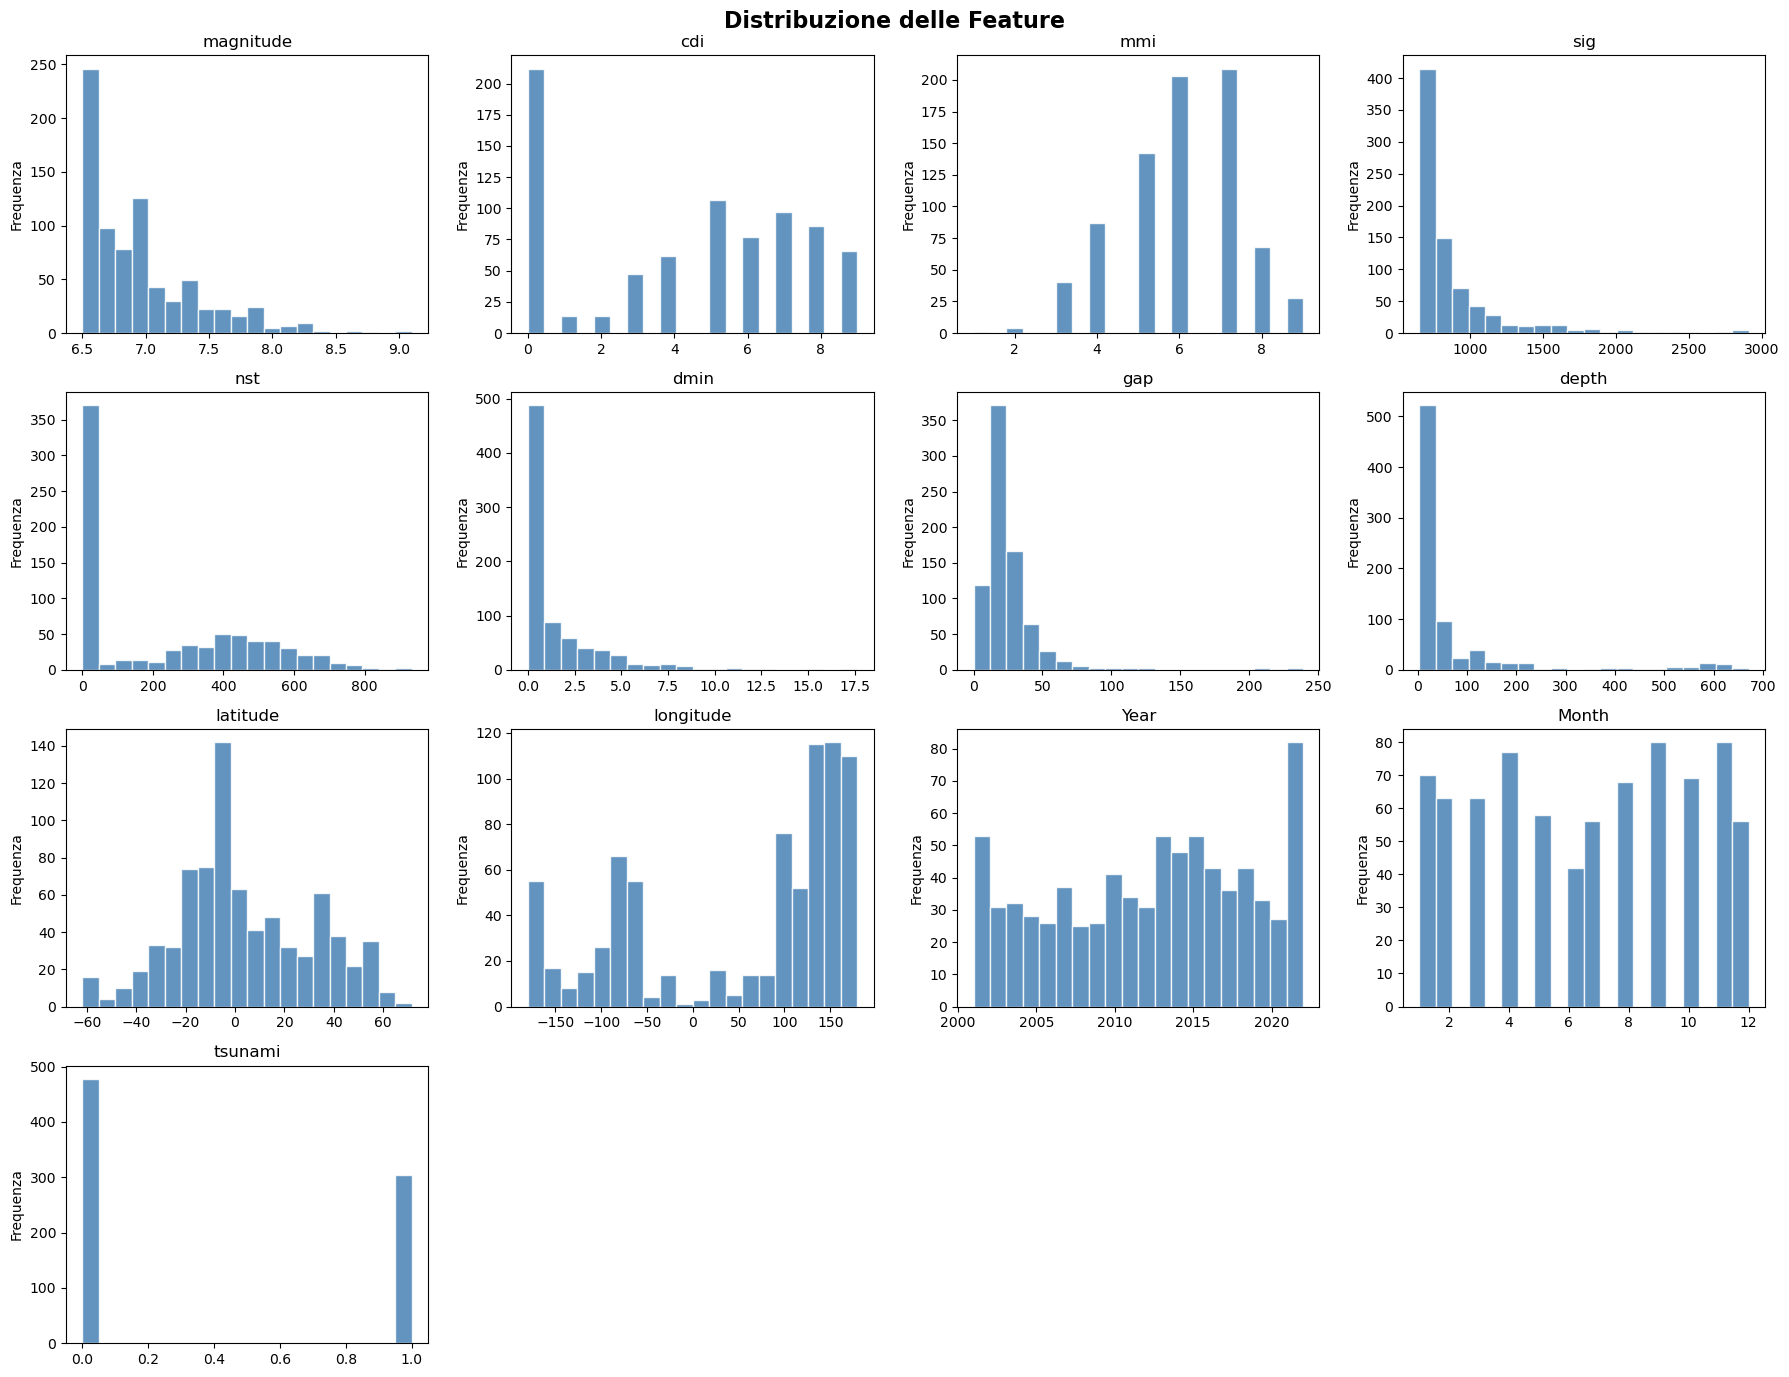

In [45]:
cols = df.columns.tolist() 
print(cols)
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
fig.suptitle('Distribuzione delle Feature', fontsize=16, fontweight='bold')

axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col)
    axes[i].set_ylabel('Frequenza')

for j in range(len(cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

- **magnitude** — concentrata tra 6.5 e 7.5, skewed a destra. La maggior parte sono terremoti di magnitudo moderata-alta.
- **cdi** — distribuzione bimodale: picco a 0 (non percepiti) e valori alti tra 5-9. Questo puo suggerirci che ci sono due classi, da una parte terremoti non percepiti, quindi 0 e quelli che sono tra 5 e 9 che sono terremoti piu forti
- **mmi** — quasi uniforme tra 2 e 9, buona copertura di tutti i livelli di intensità.
- **sig** — fortemente skewed a destra, pochi eventi molto significativi con possibili outlier estremi.
- **nst** — skewed a destra, molti terremoti rilevati da poche stazioni (zone remote o oceani).
- **dmin** — concentrata vicino a 0, la maggior parte avviene vicino a stazioni di rilevamento.
- **gap** — concentrata sotto 50°, pochi terremoti in zone con scarsa copertura strumentale.
- **depth** — fortemente skewed, quasi tutti superficiali (0-100km). Pochi eventi profondi fino a 700km.
- **latitude/longitude** — distribuzione irregolare.
- **Year** — distribuzione uniforme tra 2001 e 2022.
- **Month** — distribuzione uniforme, i terremoti non seguono stagionalità.


# 4. SKEWNESS E KURTOSIS

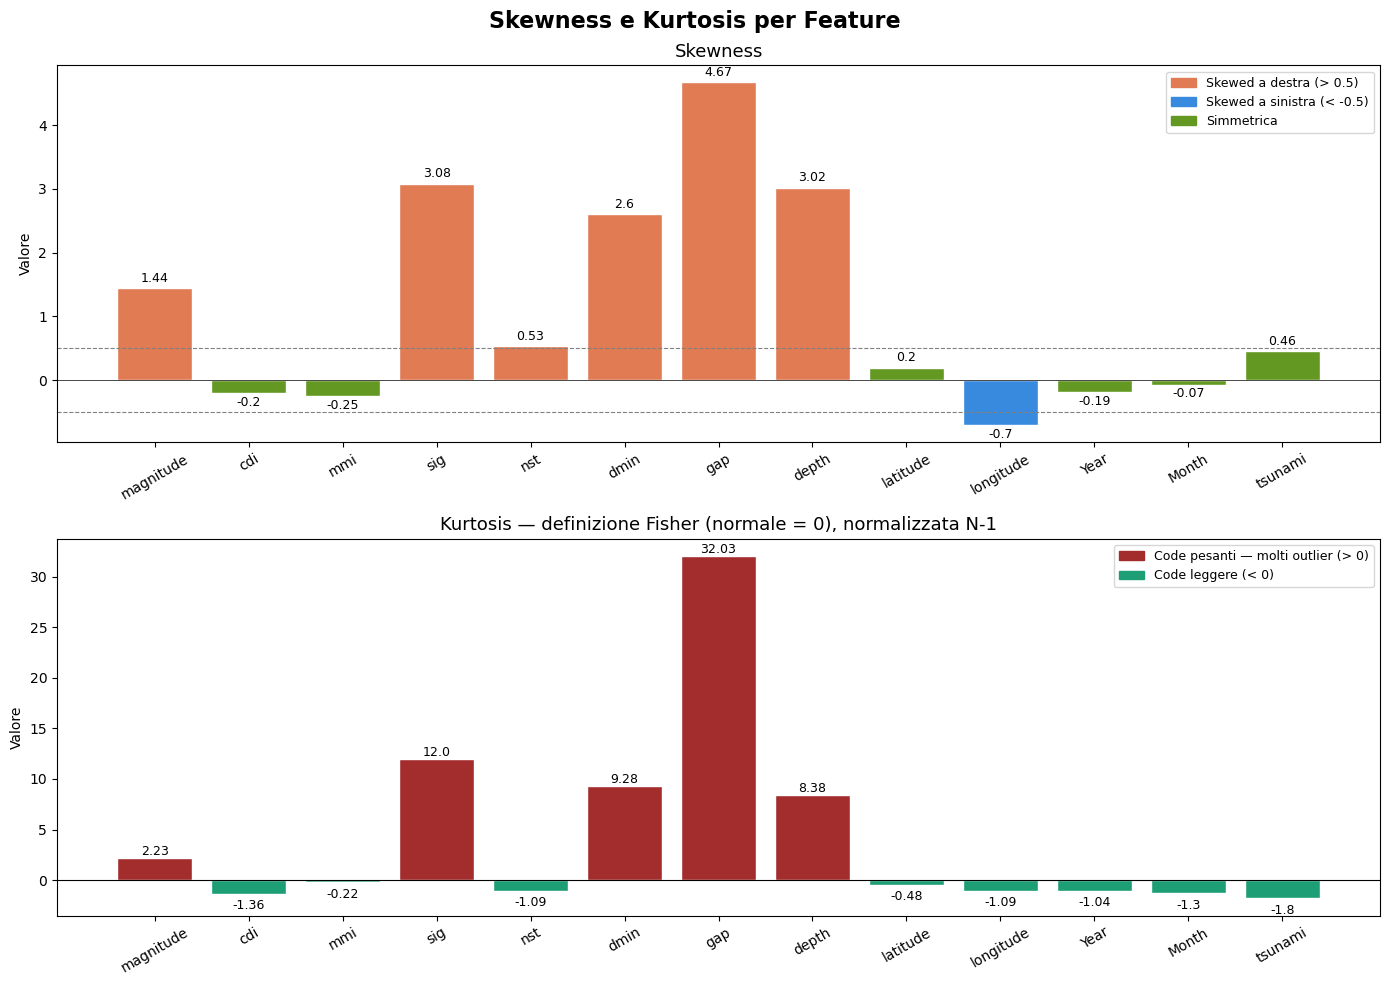

In [47]:
from matplotlib.patches import Patch

skew = df.skew().round(2)
kurt = df.kurt().round(2)

def get_skew_color(v):
    if v > 0.5:    return '#E07B54'
    elif v < -0.5: return '#378ADD'
    else:          return '#639922'

def get_kurt_color(v):
    if v > 0:  return '#A32D2D'   # code pesanti
    else:      return '#1D9E75'   # code leggere

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Skewness e Kurtosis per Feature', fontsize=16, fontweight='bold')

# Skewness
skew_colors = [get_skew_color(v) for v in skew]
axes[0].bar(skew.index, skew.values, color=skew_colors, edgecolor='white')
axes[0].axhline(0.5,  color='gray', linewidth=0.8, linestyle='--')
axes[0].axhline(-0.5, color='gray', linewidth=0.8, linestyle='--')
axes[0].axhline(0,    color='black', linewidth=0.5)
axes[0].set_title('Skewness', fontsize=13)
axes[0].set_ylabel('Valore')
axes[0].tick_params(axis='x', rotation=30)
for i, val in enumerate(skew.values):
    axes[0].text(i, val + (0.1 if val >= 0 else -0.2), str(val), ha='center', fontsize=9)
axes[0].legend(handles=[
    Patch(color='#E07B54', label='Skewed a destra (> 0.5)'),
    Patch(color='#378ADD', label='Skewed a sinistra (< -0.5)'),
    Patch(color='#639922', label='Simmetrica'),
], fontsize=9)

# Kurtosis
kurt_colors = [get_kurt_color(v) for v in kurt]
axes[1].bar(kurt.index, kurt.values, color=kurt_colors, edgecolor='white')
axes[1].axhline(0, color='black', linewidth=0.8)  # soglia a 0 non a 3
axes[1].set_title('Kurtosis — definizione Fisher (normale = 0), normalizzata N-1', fontsize=13)
axes[1].set_ylabel('Valore')
axes[1].tick_params(axis='x', rotation=30)
for i, val in enumerate(kurt.values):
    axes[1].text(i, val + (0.3 if val >= 0 else -1.5), str(val), ha='center', fontsize=9)
axes[1].legend(handles=[
    Patch(color='#A32D2D', label='Code pesanti — molti outlier (> 0)'),
    Patch(color='#1D9E75', label='Code leggere (< 0)'),
], fontsize=9)
plt.tight_layout()

plt.show()

Il metodo `.skew()` in pandas calcola l'asimmetria statistica di una distribuzione, 
ovvero misura quanto una distribuzione differisce dalla simmetria di una distribuzione 
normale (skewness = 0).

**Formula:** pandas utilizza la formula per l'asimmetria campionaria normalizzata 
per **N-1**.  


**Feature skewed a destra (> 0.5)** — coda lunga verso valori alti:
- **gap** (4.67) — asimmetria alta , quasi tutti i terremoti hanno gap basso,
  pochi casi con gap altissimo, questo si puo vedere anche nel grafico della dsitribuzione
- **sig** (3.08) — pochi eventi molto significativi trascinano la distribuzione
- **depth** (3.02) — quasi tutti i terremoti sono superficiali, pochi molto profondi
- **dmin** (2.60) — la maggior parte vicino a stazioni, pochi molto lontani
- **magnitude** (1.44) — concentrata tra 6.5-7.5, pochi eventi estremi fino a 9.0
- **nst** (0.53) — moderatamente skewed, molti terremoti rilevati da poche stazioni

**Feature simmetriche (tra -0.5 e 0.5)**:
- **cdi** (-0.20), **mmi** (-0.25), **latitude** (0.20), 
  **Year** (-0.19), **Month** (-0.07), **tsunami** (0.46)

**Feature skewed a sinistra (< -0.5)**:
- **longitude** (-0.70) — unica feature con coda verso valori bassi


La kurtosis è calcolata con il metodo `.kurt()` di pandas, che usa:
- **Definizione di Fisher** → kurtosis della distribuzione normale = 0
- **Normalizzata per N-1** → corretta per campioni piccoli (unbiased)


**Code pesanti — molti outlier (> 0)**:
- **gap** (32.03) — caso estremo, outlier molto distanti dalla media
- **sig** (12.0) — pochi eventi con significatività elevatissima
- **dmin** (9.28) — pochi terremoti molto lontani da stazioni
- **depth** (8.38) — pochi terremoti molto profondi
- **magnitude** (2.23) — pochi eventi estremi fino a 9.0

**Code leggere (< 0)**:
- **cdi** (-1.36), **nst** (-1.09), **longitude** (-1.09),
  **Year** (-1.04), **Month** (-1.30), **tsunami** (-1.80),
  **mmi** (-0.22), **latitude** (-0.48)


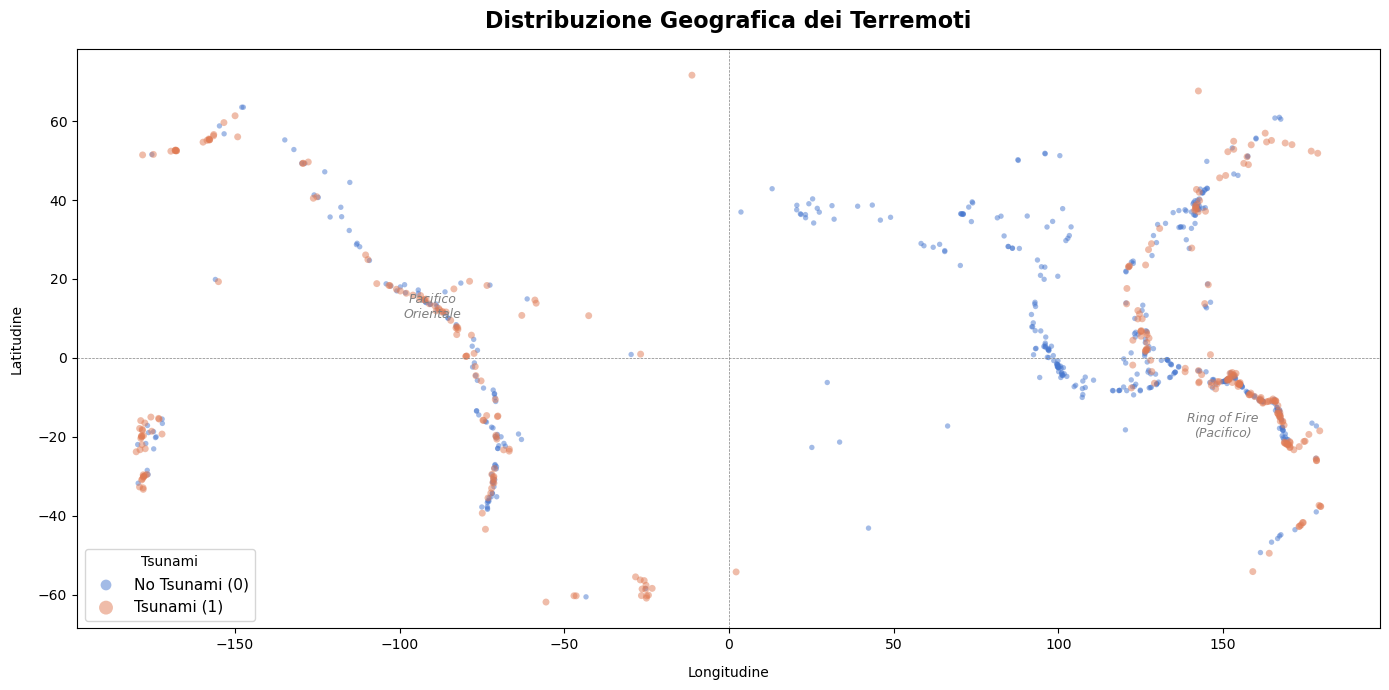

In [49]:

fig, ax = plt.subplots(figsize=(14, 7))

colors = {0: '#4878CF', 1: '#E07B54'}
labels = {0: 'No Tsunami (0)', 1: 'Tsunami (1)'}
sizes  = {0: 15, 1: 25}

for classe in [0, 1]:
    subset = df[df['tsunami'] == classe]
    ax.scatter(
        subset['longitude'], subset['latitude'],
        c=colors[classe],
        label=labels[classe],
        alpha=0.5,
        s=sizes[classe],
        edgecolors='none'
    )

ax.set_title('Distribuzione Geografica dei Terremoti', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Longitudine', labelpad=10)
ax.set_ylabel('Latitudine', labelpad=10)
ax.legend(title='Tsunami', markerscale=2, fontsize=11)

# Linee equatore e meridiano
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--', label='Equatore')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')

# Annotazioni zone principali
ax.annotate('Ring of Fire\n(Pacifico)', xy=(150, -20), fontsize=9, color='gray',
            ha='center', style='italic')
ax.annotate('Pacifico\nOrientale', xy=(-90, 10), fontsize=9, color='gray',
            ha='center', style='italic')

plt.tight_layout()
plt.show()

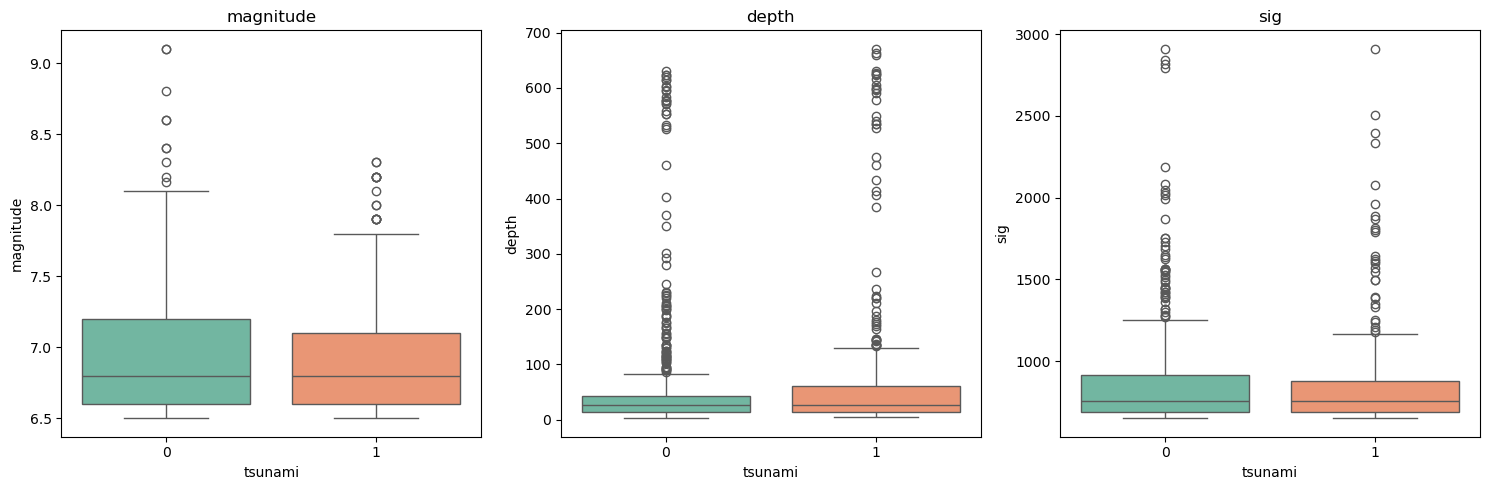

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, ['magnitude', 'depth', 'sig']):
    sns.boxplot(x='tsunami', y=col, data=df, palette='Set2', ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

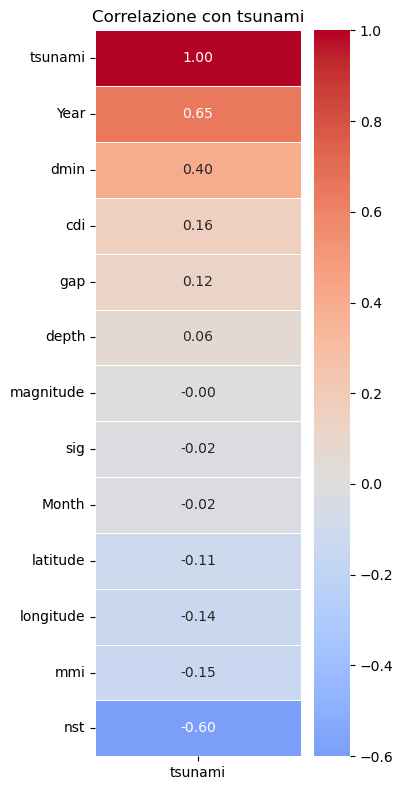

In [62]:
corr_tsunami = df.corr()[['tsunami']].sort_values('tsunami', ascending=False)

plt.figure(figsize=(4, 8))
sns.heatmap(corr_tsunami, 
            annot=True, 
            cmap='coolwarm', 
            fmt='.2f',
            linewidths=0.5,
            center=0)
plt.title('Correlazione con tsunami')
plt.tight_layout()
plt.show()